Wczytywanie obrazu

In [7]:
import os
import matplotlib.pyplot as plt
from scipy import misc
import numpy as np
from PIL import Image
from skimage import color
import skimage
path = "01_h.jpg"

if os.path.exists(path):
    img = Image.open(path).convert('RGB')
    root, extension = os.path.splitext(path)
else:
    print("Nie można znaleźć pliku 1.")
img= np.array(img)
r = img.copy()
r[:,:,1] = r[:,:,2] = 0

g = img.copy()
g[:,:,0] = g[:,:,2] = 0

b = img.copy()
b[:,:,0] = b[:,:,1] = 0

Czerwona składowa

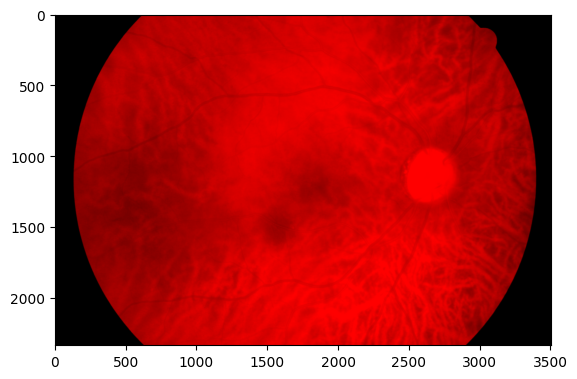

In [8]:
plt.imshow(r)

Zielona składowa

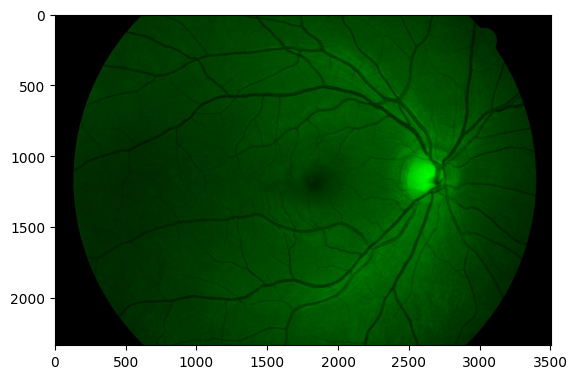

In [9]:
plt.imshow(g)

Użycie zielonej składowej oraz filtra frangiego do znalezienia naczyń krwionośnych

423100 out of 8185344 pixels are in high contrast, which means about 5.168994730093201% the eye is blood vessels


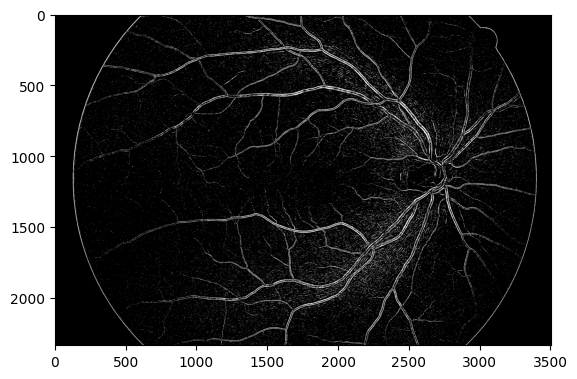

In [10]:
grey = color.rgb2gray(g)
f=skimage.filters.frangi(grey)
pixels=0
prog=0.01
contrast_pixels=0
classified_points = f.copy()
for i in range(0,f.shape[0]):
    for j in range(0,f.shape[1]):
        if f[i][j]>prog:
            contrast_pixels+=1
            classified_points[i][j]=1
        else:
            classified_points[i][j]=0
        pixels+=1
print(str(contrast_pixels) + " out of " + str(pixels) + " pixels are in high contrast, which means about " + str(contrast_pixels/pixels*100) +"%" + " the eye is blood vessels")
#plt.imshow(grey, cmap=plt.get_cmap('gray'), vmin=0, vmax=1)
plt.imshow(classified_points, cmap=plt.get_cmap('gray'), vmin=0, vmax=1)




Niebieska składowa

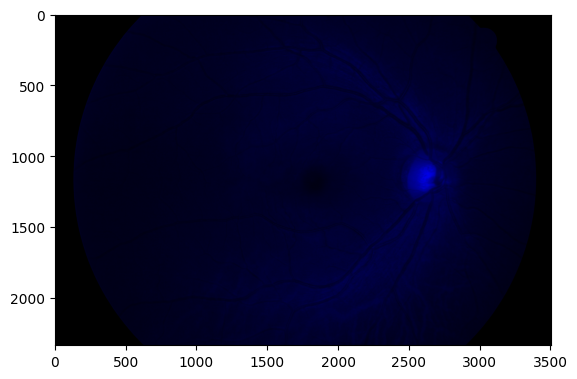

In [11]:
plt.imshow(b)

Składowe niebieskie i czerwone dostarczają nam bardzo niewiele danych, w związku z czym nie używamy ich do szukania naczyń krwionośnych

Porównanie złotego standardu z naszą maską

Zgodność maski i maski eksperckiej:  0.9023212707981485


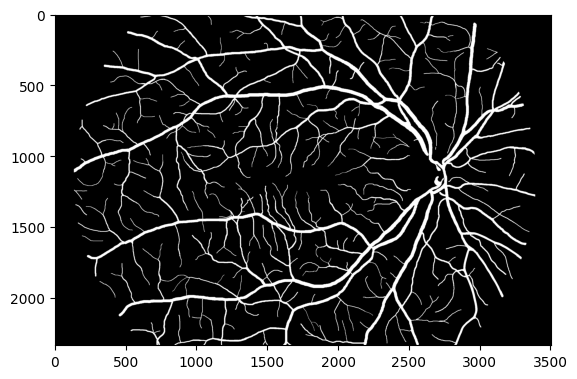

In [17]:
path = "01_h_goldstandard.bmp"
gold_mask=None
if os.path.exists(path):
    gold_mask = Image.open(path).convert('RGB')
    root, extension = os.path.splitext(path)
else:
    print("Nie można znaleźć pliku 2.")
gold_mask = np.array(gold_mask)
#print(gold_mask)
gold_maks = color.rgb2gray(gold_mask)
plt.imshow(gold_mask, cmap=plt.get_cmap('gray'), vmin=0, vmax=1)

l=0
m=0
for i in range(0,classified_points.shape[0]):
    for j in range(0,classified_points.shape[1]):
        if classified_points[i][j] == gold_mask[i][j].any():
            l+=1
        m+=1
print("Zgodność maski i maski eksperckiej: ", l/m)